# PyPSA Beispiel 4

### a. PV-Anlage vs. Flachkollektoren

Importieren Sie die notwendigen Bibliotheken und lesen Sie die Input Daten ein ('data_PyPSA_04.csv')

In [1]:
import numpy as np
import pandas as pd
import pypsa

In [2]:
df_data = pd.read_csv('data_PyPSA_04.csv')

<Axes: >

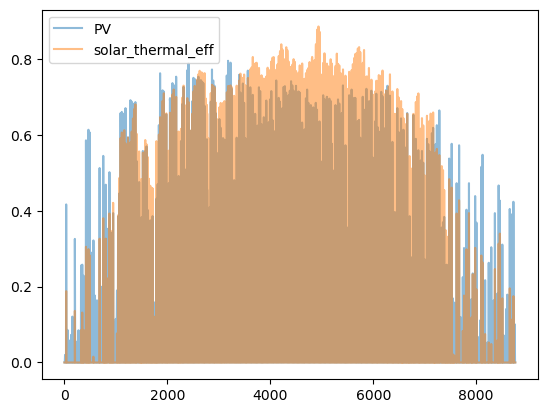

In [3]:
df_data.loc[:,["PV","solar_thermal_eff"]].plot(alpha=0.5)

Implementieren Sie das Basissystem, sowie die PV-Anlage, die Flachkollektoren und den Heizstab.

In [4]:
boiler_p_nom        = np.inf
boiler_eff          = 0.85
gas_rate            = 0.123 #€/kWh

electricity_rate    = 0.409 #€/kWh
grid_p_nom          = 15    #kW 

interest_rate       = 0.02

pv_invest           = 1000  #€/kWp
pv_lifespan         = 25    #Jahre
pv_annuity          = pv_invest*((1+interest_rate)**pv_lifespan)*interest_rate/((1+interest_rate)**pv_lifespan-1)
pv_p_per_m2         = 0.2   #kWp/m2

heating_rod_eff     = 0.99  #Effizienz des Heizstabes
heating_rod_p_nom   = 3     #Leistung des Heizstabes in kW

col_invest          = 600   #€/kW_th (Spitzenlast bei G = 1000 W/m2 und 35° Neigung Südausrichtung)
col_lifespan        = 20    #Jahre
col_annuity         = col_invest*((1+interest_rate)**col_lifespan)*interest_rate/((1+interest_rate)**col_lifespan-1)
col_p_per_m2        = 0.805 #kWp_th/m2 (Bei 35° Dachneigung Südseite)

heat_store_loss     = 0.005
heat_store_e_nom    = 8.55   # kWh (entspricht einem 300 l Pufferspeicher bei einer Temperaturspreizung von 25 K)

In [5]:
network = pypsa.Network()
network.set_snapshots(df_data.index)

network.add('Bus', name = 'thermal')
network.add('Bus', name = 'electricity')

network.add('Load', name = 'heating_load', 
            bus = 'thermal', 
            p_set = df_data["heat_load"])
network.add('Load', name = 'electrical_load', 
            bus = 'electricity', 
            p_set = df_data["electrical_load"])


network.add('Generator', name = 'grid',
            bus = 'electricity',
            p_nom = grid_p_nom,
            marginal_cost = electricity_rate)
network.add('Generator',  name = 'boiler',
            bus = 'thermal', 
            p_nom = boiler_p_nom, 
            marginal_cost = gas_rate/boiler_eff)
network.add('Generator', name = 'PV',
            bus = 'electricity', 
            p_nom_extendable = True, 
            capital_cost = pv_annuity, 
            p_max_pu = df_data["PV"])
network.add('Generator', name = 'collector', 
            bus = 'thermal', 
            p_nom_extendable = True, 
            capital_cost = col_annuity, 
            p_max_pu = df_data["solar_thermal_eff"])

network.add('Link', name = 'heating_rod',
            bus0 = 'electricity', 
            bus1 = 'thermal', 
            p_nom = heating_rod_p_nom,  
            efficiency = heating_rod_eff)

network.add('Store',  name = 'heat_store',
            bus = 'thermal', 
            e_nom = heat_store_e_nom, 
            standing_loss = heat_store_loss)

Index(['heat_store'], dtype='object')

Optimieren Sie das System zunächst ohne Begrenzung der Dachfläche

In [6]:
network.optimize(solver_name="gurobi", method = 1, threads = 1)

Index(['heating_rod'], dtype='object', name='Link')
Index(['heat_store'], dtype='object', name='Store')
Index(['thermal', 'electricity'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - method: 1
 - threads: 1
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 38.02it/s]
INFO:linopy.io: Writing time: 0.77s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 11974 iterations and 1.26 seconds (0.92 work units)


INFO:gurobipy:Solved in 11974 iterations and 1.26 seconds (0.92 work units)


Optimal objective  3.984856519e+03


INFO:gurobipy:Optimal objective  3.984856519e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61322 primals, 122642 duals
Objective: 3.98e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

Lassen Sie sich die Auslegung der PV-Anlage sowie der Flachkollektoren ausgeben und berechnen Sie die benötigte Dachfläche

In [7]:
network.generators.p_nom_opt

Generator
grid         15.000000
boiler             inf
PV            5.601445
collector     1.845980
Name: p_nom_opt, dtype: float64

In [8]:
print("PV:", round(network.generators.p_nom_opt.PV / pv_p_per_m2,2),"m2")
print("Flachkollektor:",round(network.generators.p_nom_opt.collector / col_p_per_m2,2),"m2")

PV: 28.01 m2
Flachkollektor: 2.29 m2


<Axes: xlabel='snapshot'>

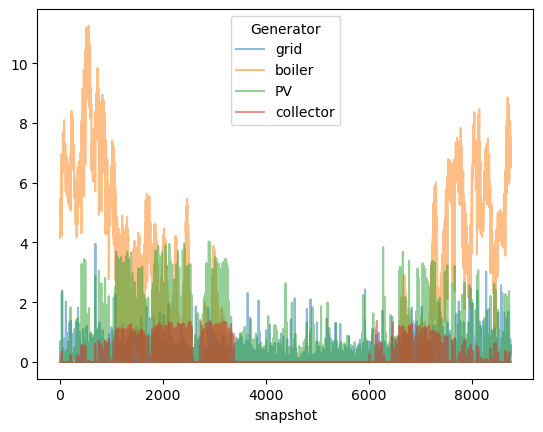

In [9]:
network.generators_t.p.plot(alpha=0.5)

Erstellen Sie nun eine Custom Constraint, welche die Dachflächen-Limitierung abbildet. <br>
Erstellen Sie hierzu zunächst eine Kopie des PyPSA Netzwerks als Modell. <br>
Fügen Sie diesem Modell eine Nebenbedingung hinzu und lösen Sie das Modell.

In [10]:
model = network.optimize.create_model()

Index(['heating_rod'], dtype='object', name='Link')
Index(['heat_store'], dtype='object', name='Store')
Index(['thermal', 'electricity'], dtype='object', name='Bus')


In [11]:
model_pv_p_nom = model.variables['Generator-p_nom'].at['PV']
model_col_p_nom = model.variables['Generator-p_nom'].at['collector']

constraint_expression = model_pv_p_nom/pv_p_per_m2 +  model_col_p_nom/col_p_per_m2 <= 20 
model.add_constraints(constraint_expression, name = 'Flächenbegrenzung')

Constraint `Flächenbegrenzung`
------------------------------
+5 Generator-p_nom[PV] + 1.242 Generator-p_nom[collector] ≤ 20

Lassen Sie sich erneut die Auslegung ausgeben und berechnen Sie ob die Dachflächenlimitierung eingehalten wurde

In [12]:
network.optimize.solve_model(solver_name='gurobi', threads = 1, method = 1)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - threads: 1
 - method: 1
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 43.92it/s]
INFO:linopy.io: Writing time: 0.7s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 7849 iterations and 0.47 seconds (0.29 work units)


INFO:gurobipy:Solved in 7849 iterations and 0.47 seconds (0.29 work units)


Optimal objective  4.007804845e+03


INFO:gurobipy:Optimal objective  4.007804845e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 61322 primals, 122643 duals
Objective: 4.01e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-fix-p-lower, Link-fix-p-upper, Store-fix-e-lower, Store-fix-e-upper, Store-energy_balance, Flächenbegrenzung were not assigned to the network.


('ok', 'optimal')

In [13]:
print("PV: \n",round(network.generators.p_nom_opt.PV,),"kWp \n", round(network.generators.p_nom_opt.PV / pv_p_per_m2,2),"m2")
print("Flachkollektor: \n",round(network.generators.p_nom_opt.collector,2),"max. kW_th \n",round(network.generators.p_nom_opt.collector / col_p_per_m2,2),"m2")

PV: 
 3 kWp 
 16.98 m2
Flachkollektor: 
 2.43 max. kW_th 
 3.02 m2


### b. Wärmepumpe

Implementieren Sie nun die Wärmepumpe. <br>
Verwenden Sie hierzu die selben Daten wie aus Übung PyPSA 03. <br> 
Beachten Sie dieses mal jedoch zusätzlich die minimale thermische Leistung über das Attribut 'p_min_pu'.

In [14]:
T_VL        =   55 #°C
temp        =   [ -20, -15, -10,  -7,   2,   7,  10,  20,  30,  35] #°C
el_power    =   [3.87,4.20,4.45,4.60,2.25,2.23,2.27,2.33,2.27,2.27] #kW
cop         =   [1.81,1.98,2.18,2.30,2.83,3.40,3.66,4.80,6.37,6.37]
min_th_p    =   [2.70,2.74,2.48,2.32,3.03,3.51,3.84,5.07,6.10,6.10] #kW
hp_p_nom    =   1.56 #kW

<Axes: >

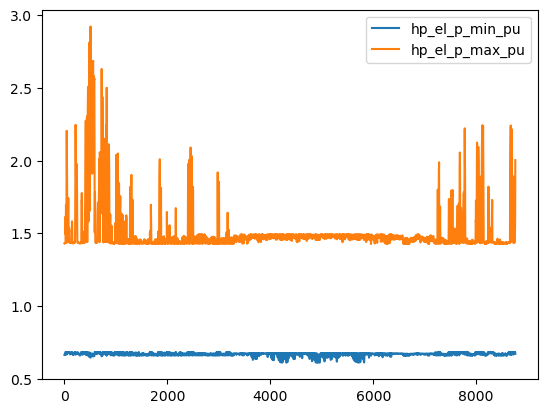

In [15]:
df_data["hp_th_p_min"]     = np.interp(df_data['temperature'],temp,min_th_p)
df_data["hp_el_p_min_pu"]  = (df_data['hp_th_p_min'] / (df_data["hp_COP"] * hp_p_nom)) 
df_data.loc[:,["hp_el_p_min_pu","hp_el_p_max_pu"]].plot()

In [16]:
heatpump_eff        = df_data["hp_COP"] 
heatpump_p_max_pu   = df_data["hp_el_p_max_pu"] 
heatpump_p_min_pu   = df_data["hp_el_p_min_pu"]

network.add('Link', name = 'heatpump', 
            bus0 = 'electricity', 
            bus1 = 'thermal',
            p_nom = hp_p_nom, 
            committable = True,  
            p_max_pu = heatpump_p_max_pu,
            p_min_pu = heatpump_p_min_pu, 
            efficiency = heatpump_eff)

Index(['heatpump'], dtype='object')

Erstellen Sie nun erneut eine Kopie des Netzwerks als Modell und fügen Sie diesem neben der Flächenbegrenzung ebenfalls eine Nebenbedingung zur Einhaltung des GEG hinzu.<br>
(Der Heizstab soll als nicht erneuerbare Technologie betrachtet werden)

In [17]:
model = network.optimize.create_model()
#Flächenbegrenzung
model_pv_p_nom  = model.variables["Generator-p_nom"].at['PV']
model_col_p_nom = model.variables["Generator-p_nom"].at['collector']

constraint_expression = 20 >= model_pv_p_nom/pv_p_per_m2 + model_col_p_nom/col_p_per_m2
model.add_constraints(constraint_expression, name="Flächenbegrenzung")

#65% EE
model_boiler_p  = model.variables["Generator-p"].sel(Generator='boiler')
model_hr_p      = model.variables["Link-p"].sel(Link='heating_rod')
con_ee_limit = (sum(model_boiler_p[t] + model_hr_p[t]*heating_rod_eff 
                    for t in df_data.index) 
                <= 0.35 * df_data["heat_load"].sum())
model.add_constraints(con_ee_limit, name="EE-Limit")

Index(['heating_rod', 'heatpump'], dtype='object', name='Link')
Index(['heat_store'], dtype='object', name='Store')
Index(['thermal', 'electricity'], dtype='object', name='Bus')
/opt/conda/lib/python3.12/site-packages/linopy/variables.py:196: FutureWarning:

Accessing a single value with `Variable[...]` and return type ScalarVariable is deprecated. In future, this will return a Variable.To get a ScalarVariable use `Variable.at[...]` instead.



Constraint `EE-Limit`
---------------------
+1 Generator-p[0, boiler] + 0.99 Link-p[0, heating_rod] + 1 Generator-p[1, boiler] ... +0.99 Link-p[8758, heating_rod] + 1 Generator-p[8759, boiler] + 0.99 Link-p[8759, heating_rod] ≤ 7851.441290000001

Lösen Sie das Modell

In [18]:
network.optimize.solve_model(solver_name='gurobi', method = 1, threads = 1)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - method: 1
 - threads: 1
INFO:linopy.io:Writing objective.
Writing binary variables.: 100%|██████████| 3/3 [00:00<00:00, 145.08it/s]
INFO:linopy.io: Writing time: 1.06s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Optimal solution found (tolerance 1.00e-04)


INFO:gurobipy:Optimal solution found (tolerance 1.00e-04)


Best objective 3.607617750363e+03, best bound 3.607299353279e+03, gap 0.0088%


INFO:gurobipy:Best objective 3.607617750363e+03, best bound 3.607299353279e+03, gap 0.0088%
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 96362 primals, 0 duals
Objective: 3.61e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:No shadow prices were assigned to the network.


('ok', 'optimal')

Überprüfen Sie ob die Nebenbedingungen eingehalten wurden

In [19]:
print("Genutzte Dachfläche:",round(network.generators.p_nom_opt.PV / pv_p_per_m2 + network.generators.p_nom_opt.collector / col_p_per_m2,2),"m2")
print("Nicht-EE-Anteil:",round(network.generators_t.p.boiler.sum() / df_data["heat_load"].sum()*100,2),"%")
print("Wärmepumpen-Anteil:", round(network.links_t.p1.heatpump.sum() * -1 / df_data["heat_load"].sum() * 100,2),"%")


Genutzte Dachfläche: 20.0 m2
Nicht-EE-Anteil: 34.71 %
Wärmepumpen-Anteil: 65.41 %


Lassen Sie sich die Auslegung der PV-Anlage und der Flachkollektoren ausgeben und plotten Sie sich die Leistung der Wärmepumpe und des Heizstabs

In [ ]:
network.generators.p_nom_opt

In [ ]:
network.links_t.p0.loc[:,["heating_rod","heatpump"]].plot(alpha=0.5)

Ändern Sie das Netzwerk derart ab, sodass der Heizstab nur noch durch die PV-Erzeugung betrieben werden kann. <br>
Nutzen Sie das Attribut 'overwrite = True' damit Sie das Netzwerk nicht komplett neu aufbauen müssen.

In [ ]:
model = network.optimize.create_model()

model_pv_p_nom  = model.variables["Generator-p_nom"]['PV']
model_col_p_nom = model.variables["Generator-p_nom"]['collector']

model_boiler_p  = model.variables["Generator-p"].sel(Generator='boiler')
model_hr_p      = model.variables["Link-p"].sel(Link='heating_rod')


constraint_expression = 20 >= model_pv_p_nom/pv_p_per_m2 + model_col_p_nom/col_p_per_m2
model.add_constraints(constraint_expression, name="Flächenbegrenzung")

con_ee_limit = sum(model_boiler_p[t] for t in df_data.index) <=  0.35 * df_data["heat_load"].sum()
model.add_constraints(con_ee_limit, name="EE-Limit")

network.optimize.solve_model(solver_name='gurobi', method = 1, threads = 1)

Erzeugen Sie sich erneut eine Kopie des Netzwerks als Modell und fügen die notwendigen Nebenbedingungen hinzu

In [ ]:
print("Genutzte Dachfläche:",round(network.generators.p_nom_opt.PV / pv_p_per_m2 + network.generators.p_nom_opt.collector / col_p_per_m2,2),"m2")
print("Nicht-EE-Anteil:",round(network.generators_t.p.boiler.sum() / df_data["heat_load"].sum()*100,2),"%")


Überprüfen Sie ob die Nebenbedingungen eingehalten wurden und lassen Sie sich die Leistung der Wärmepumpe und des Heizstabs plotten

In [ ]:
network.links_t.p0.loc[:,["heating_rod","heatpump"]].plot(alpha=0.5)